In [4]:
pip install tf-nightly[and-cuda]


/bin/bash: /home/eee75055/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Note: you may need to restart the kernel to use updated packages.


In [5]:
#!pip install tensorflow==2.20.0

In [6]:
pip install uv

/bin/bash: /home/eee75055/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Note: you may need to restart the kernel to use updated packages.


In [7]:
!pip install kagglehub opencv-python scikit-learn pandas numpy matplotlib seaborn pillow imbalanced-learn

# Additional ML utilities
!pip install scikit-image albumentations grad-cam

# For experiment tracking and visualization
!pip install mlflow wandb tensorboard


/bin/bash: /home/eee75055/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
/bin/bash: /home/eee75055/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
  Using cached nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_runtime_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_cupti_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cudnn_cu12-9.10.2.21-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_cublas_cu12-12.8.4.1-py3-none-manylinux_2_27_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cufft_cu12-11.3.3.83-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_curand_cu12-10.3.9.90-py3-none-manylinux_2_27_x86_64.whl.metadata (1.7 kB)
  Usin

# Tensorflow check

In [8]:
import tensorflow as tf
print(f"TensorFlow {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")
print("GPU ready for wafer CNN training!")


TensorFlow 2.20.0
GPUs: []
GPU ready for wafer CNN training!


In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iamrajanjha/wm811kwafermapimages")

print("Path to dataset files:", path)

/home/eee75055/tf_cuda_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/eee75055/.cache/kagglehub/datasets/iamrajanjha/wm811kwafermapimages/versions/1


In [10]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # CPU mode
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

print(f"TensorFlow {tf.__version__} - CPU ready")
print("WM-811K dataset loaded!")

TensorFlow 2.20.0 - CPU ready
WM-811K dataset loaded!


In [11]:
# Path to your downloaded dataset (Windows cache → WSL mount)
dataset_path = Path("/home/eee75055/.cache/kagglehub/datasets/iamrajanjha/wm811kwafermapimages/versions/1")
# Colab dataset_path = Path("/root/.cache/kagglehub/datasets/iamrajanjha/wm811kwafermapimages/versions/1/waferimages/waferimages")
#Windows -#"/mnt/c/Users/arrun/.cache/kagglehub/datasets/iamrajanjha/wm811kwafermapimages/versions/1/waferimages/waferimages"

classes = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Near-full', 'Scratch', 'none']
class_to_idx = {cls: i for i, cls in enumerate(classes)}

print("Dataset structure:")
for class_dir in dataset_path.rglob("training/*"):
    if class_dir.is_dir():
        count = len(list(class_dir.glob("*")))
        print(f"  {class_dir.name}: {count} images")


Dataset structure:
  Scratch: 501 images
  Center: 3464 images
  Near-full: 54 images
  Loc: 1624 images
  Edge-Loc: 2427 images
  Edge-Ring: 8556 images
  none: 36730 images
  Donut: 409 images
  Random: 609 images


# Normalization

In [12]:
def load_wafer_image(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    # Resize to 260x260 (your model input)
    img = cv2.resize(img, (260, 260))
    # Normalize to 0-1
    img = img.astype(np.float32) / 255.0
    return img[:, :, np.newaxis]  # Add channel dim

# Load all training data
X_train, y_train = [], []
for class_dir in dataset_path.rglob("training/*"):
    if class_dir.is_dir():
        cls_idx = class_to_idx[class_dir.name]
        for img_path in class_dir.glob("*.png"):
            wafer = load_wafer_image(img_path)
            if wafer is not None:
                X_train.append(wafer)
                y_train.append(cls_idx)

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"Loaded {len(X_train)} wafer maps")
print(f"Shape: {X_train.shape} (N, 260, 260, 1)")
print(f"Classes: {np.bincount(y_train)} per defect type")


Loaded 54374 wafer maps
Shape: (54374, 260, 260, 1) (N, 260, 260, 1)
Classes: [ 3464   409  2427  8556  1624   609    54   501 36730] per defect type


# Visuzlization of wafer defects

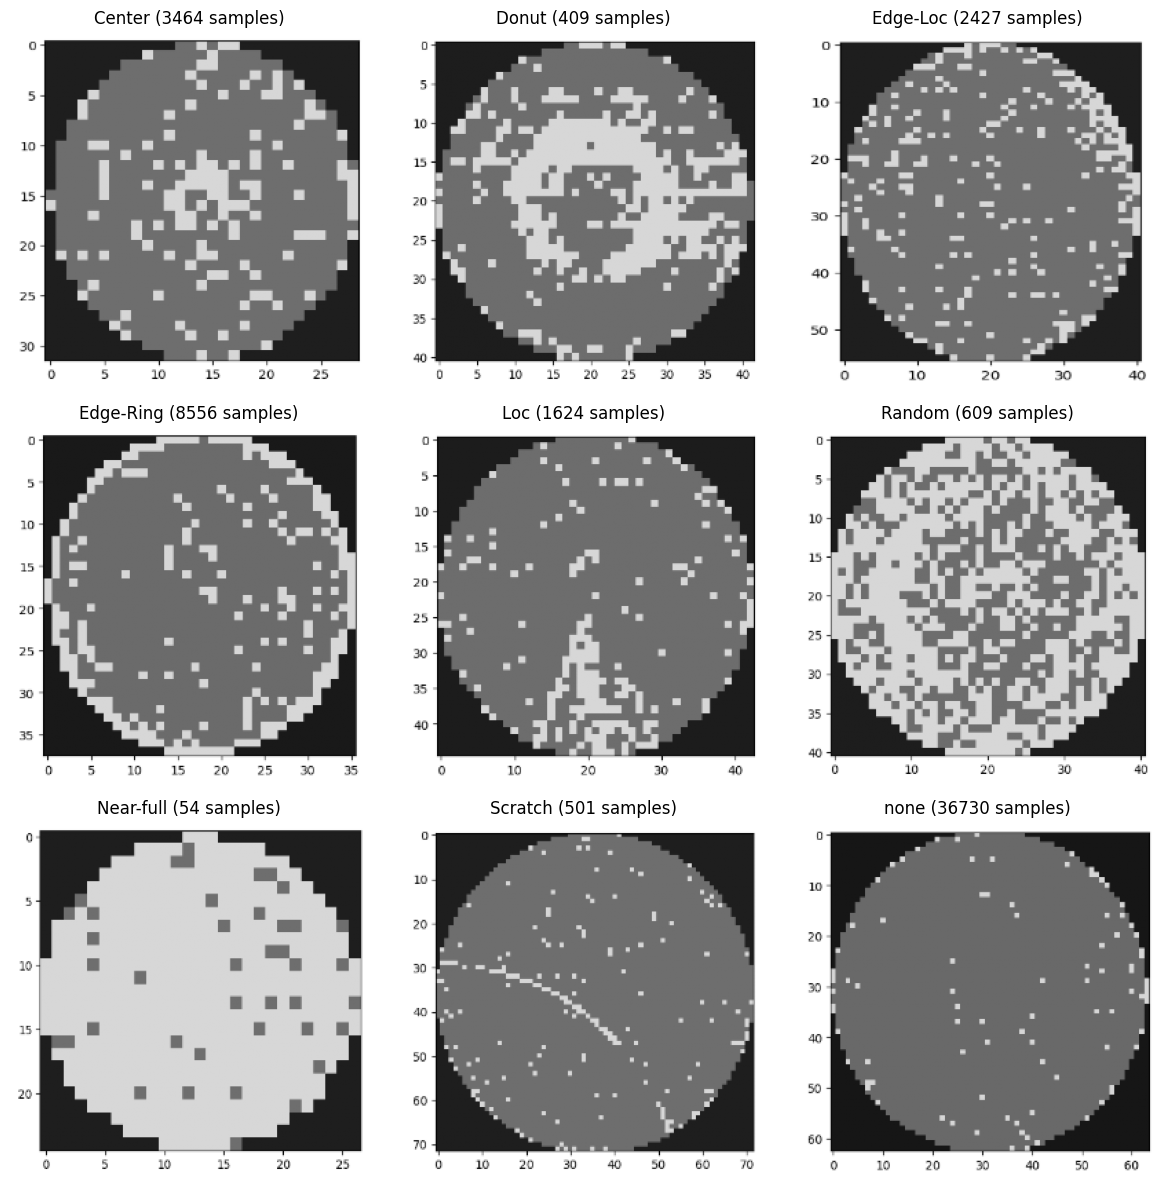

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i, cls_name in enumerate(classes):
    ax = axes[i//3, i%3]
    # Find example
    mask = y_train == i
    if mask.sum() > 0:
        idx = np.where(mask)[0][0]
        ax.imshow(X_train[idx].squeeze(), cmap='gray')
        ax.set_title(f"{cls_name} ({mask.sum()} samples)")
        ax.axis('off')
plt.tight_layout()
plt.show()

# Grayscale to RGB

/tmp/ipykernel_8792/3178788483.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colored = cm.get_cmap(cmap)(norm_img)


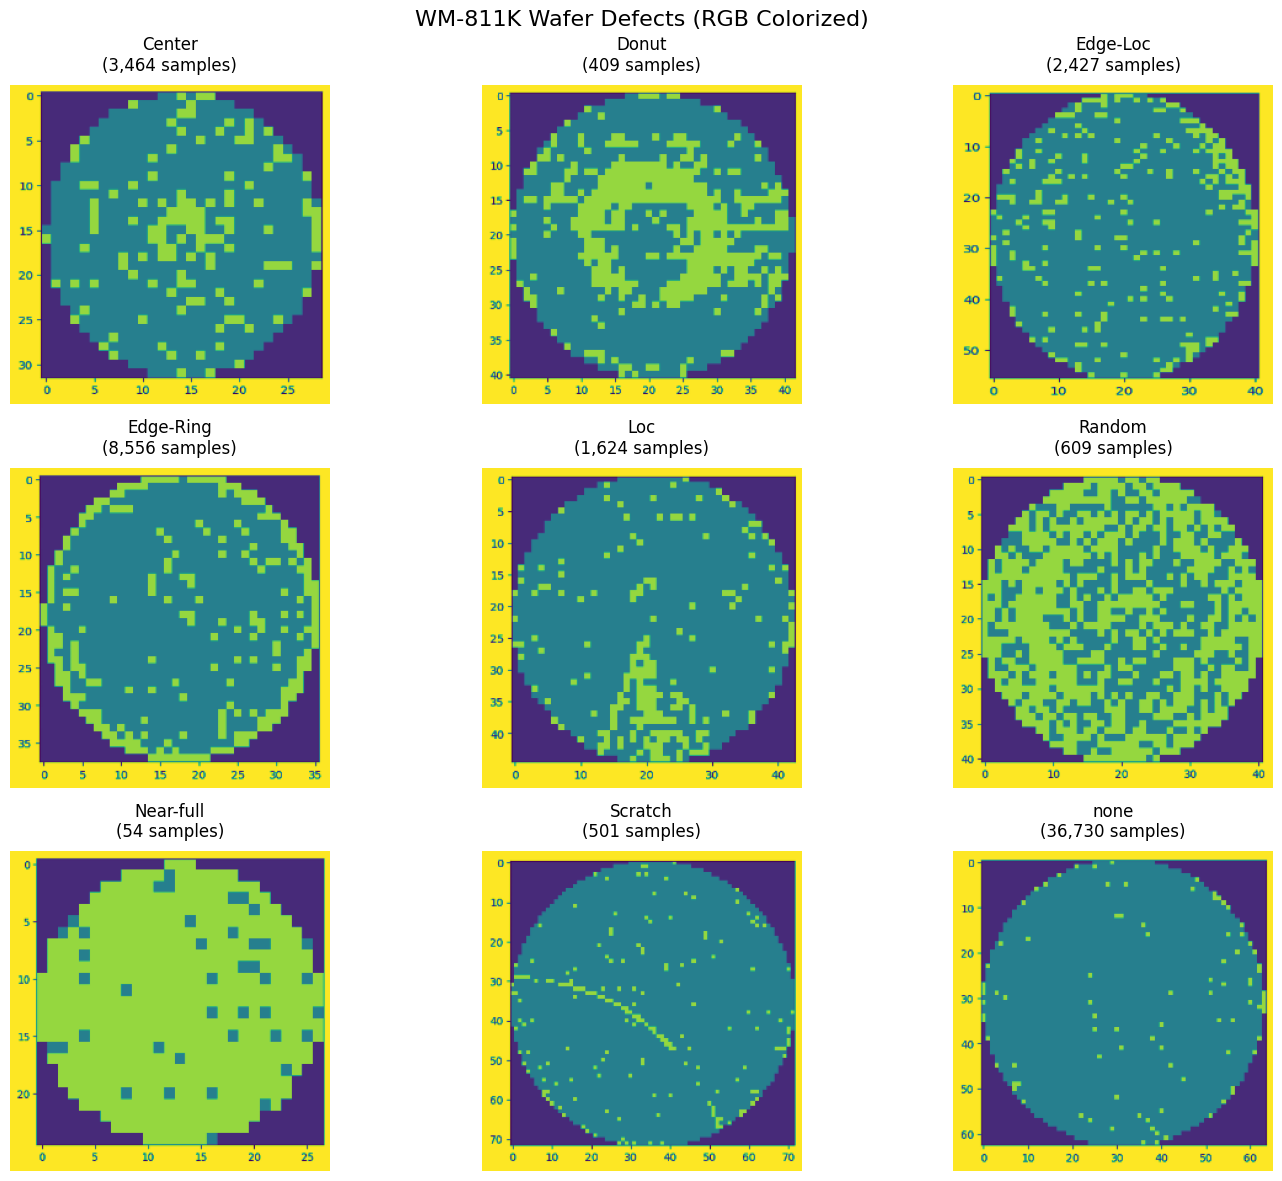

In [14]:
def grayscale_to_rgb(gray_img, cmap='viridis'):
    """Convert grayscale wafer to RGB using colormap"""
    from matplotlib.colors import to_rgb
    import matplotlib.cm as cm
    
    # Normalize grayscale to 0-1
    norm_img = gray_img.squeeze()
    
    # Apply colormap
    colored = cm.get_cmap(cmap)(norm_img)
    # Remove alpha channel
    rgb_img = (colored[:,:,:3] * 255).astype(np.uint8)
    return rgb_img

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, cls_name in enumerate(classes[:9]):
    ax = axes[i]
    
    # Find first example of this class
    mask = (y_train == i)
    if mask.sum() > 0:
        idx = np.where(mask)[0][0]
        
        # Convert grayscale → RGB
        rgb_wafer = grayscale_to_rgb(X_train[idx])
        ax.imshow(rgb_wafer)
        
        # Add class info
        ax.set_title(f"{cls_name}\n({mask.sum():,} samples)", fontsize=12, pad=10)
        ax.axis('off')

plt.suptitle('WM-811K Wafer Defects (RGB Colorized)', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


# Multi-Colormap Visualization

/tmp/ipykernel_8792/3178788483.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colored = cm.get_cmap(cmap)(norm_img)


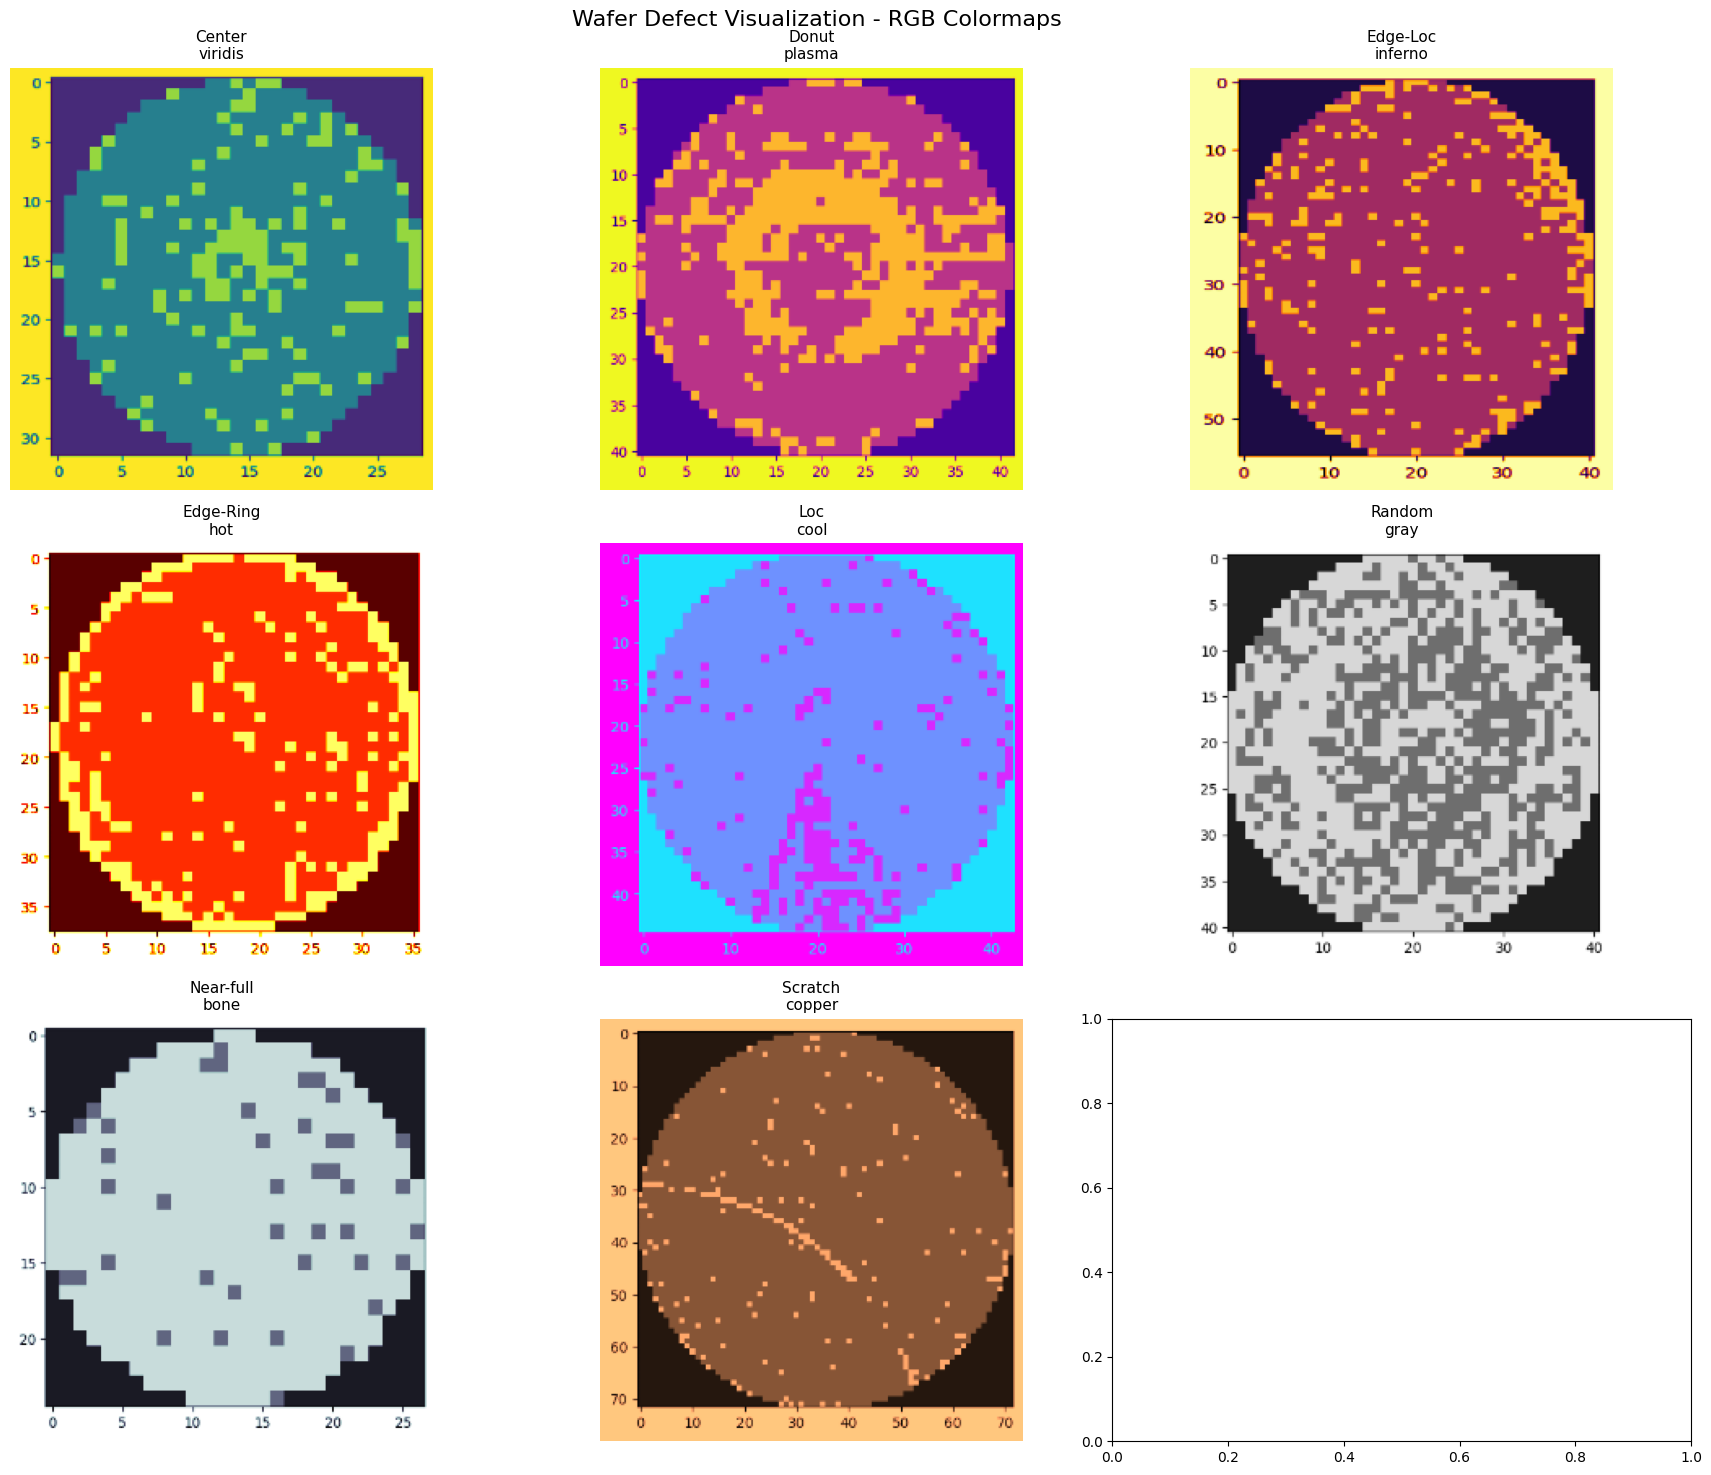

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
cmaps = ['viridis', 'plasma', 'inferno', 'hot', 'cool', 'gray', 'bone', 'copper']

for i, (cmap, ax) in enumerate(zip(cmaps, axes.ravel())):
    if i >= len(classes):
        ax.axis('off')
        continue
        
    mask = (y_train == i)
    if mask.sum() > 0:
        idx = np.where(mask)[0][0]
        rgb_wafer = grayscale_to_rgb(X_train[idx], cmap)
        ax.imshow(rgb_wafer)
        ax.set_title(f"{classes[i]}\n{cmap}", fontsize=11)
        ax.axis('off')

plt.suptitle('Wafer Defect Visualization - RGB Colormaps', fontsize=16)
plt.tight_layout()
plt.show()


# Optimzed Wafer CNN

contains nine defect pattern classes: Center, Loc, Edge-Loc, Edge-Ring, Scratch, Random, Near-full, Donut, and None (normal). Different patterns indicate specific process failures – for example, scratch patterns suggest improper wafer handling, edge-rings indicate layer misalignment, and center patterns point to chemical-mechanical planarization uniformity issues.

The training set contained only normal wafers (80% of all None-type data). Validation and test sets included the remaining normal samples plus equal amounts of each defect type. Since this is one-class classification, all defect types were collapsed into a single "defect" label.

Images were preprocessed by converting pixel values to three one-hot channels and resizing to 64×64. To find classification thresholds, the authors calculated training set statistics, found the upper anomaly score limit where recall=1, then decreased it to maximize F1 score.

In [16]:
# Check your actual class distribution
print("Class range check:")
print(f"Labels min: {y_train.min()}, max: {y_train.max()}")
print(f"Unique classes: {np.unique(y_train)}")
print(f"Class counts: {np.bincount(y_train)}")
print(f"Total classes needed: {y_train.max() + 1}")

# WM-811K classes (9 total)
classes = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Near-full', 'Scratch', 'none']
print(f"Expected: {len(classes)} classes")


Class range check:
Labels min: 0, max: 8
Unique classes: [0 1 2 3 4 5 6 7 8]
Class counts: [ 3464   409  2427  8556  1624   609    54   501 36730]
Total classes needed: 9
Expected: 9 classes


In [17]:
# Match WM-811K 9 classes (0-8)
model = tf.keras.Sequential([
    tf.keras.Input(shape=(260, 260, 1)),
    tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2),
    
    tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2),
    
    tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(9, activation='softmax')  # ✅ CHANGED: 6 → 9 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 260, 260, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 260, 260, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 260, 260, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 130, 130, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 130, 130, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 130, 130, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 130, 130, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 65, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 65, 65, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,393 (548.41 KB)

 Trainable params: 140,201 (547.66 KB)

 Non-trainable params: 192 (768.00 B)

In [18]:
# Display model summary
print("Model Architecture Summary:")
model.summary()

Model Architecture Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 260, 260, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 260, 260, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 260, 260, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 130, 130, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 130, 130, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 130, 130, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 130, 130, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 65, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 65, 65, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,393 (548.41 KB)

 Trainable params: 140,201 (547.66 KB)

 Non-trainable params: 192 (768.00 B)

# Visulize the CNN

In [ ]:

# Visualize the model architecture (requires graphviz)
try:
    plot_model(model, to_file='wafer_defect_cnn.png', 
               show_shapes=True, show_layer_names=True,
               rankdir='TB', expand_nested=True, dpi=96)
    print("Model diagram saved as 'wafer_defect_cnn.png'")
except Exception as e:
    print(f"Could not create visual model: {e}")

# Create a more detailed visualization with layer information
def visualize_layer_structure():
    layers_info = []
    for i, layer in enumerate(model.layers):
        if hasattr(layer, 'output_shape'):
            layers_info.append({
                'layer': type(layer).__name__,
                'input_shape': layer.input_shape,
                'output_shape': layer.output_shape,
                'params': layer.count_params() if hasattr(layer, 'count_params') else 0
            })
    
    print("\nDetailed Layer Analysis:")
    for i, info in enumerate(layers_info):
        print(f"Layer {i+1}: {info['layer']}")
        print(f"  Input: {info['input_shape']}")
        print(f"  Output: {info['output_shape']}")
        print(f"  Parameters: {info['params']:,}")

# Run detailed analysis
visualize_layer_structure()

# Create a conceptual flow diagram
def create_conceptual_flow():
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Define positions for each block
    blocks = [
        {'name': 'Input', 'pos': (0.5, 0.9), 'size': (1, 0.1)},
        {'name': 'Conv Block 1\n(32×2)', 'pos': (0.5, 0.7), 'size': (1, 0.1)},
        {'name': 'MaxPool', 'pos': (0.5, 0.6), 'size': (1, 0.05)},
        {'name': 'Conv Block 2\n(64×2)', 'pos': (0.5, 0.5), 'size': (1, 0.1)},
        {'name': 'MaxPool', 'pos': (0.5, 0.4), 'size': (1, 0.05)},
        {'name': 'Conv Block 3\n(128×1)', 'pos': (0.5, 0.3), 'size': (1, 0.1)},
        {'name': 'GAP', 'pos': (0.5, 0.2), 'size': (1, 0.05)},
        {'name': 'Classifier\n(9 classes)', 'pos': (0.5, 0.1), 'size': (1, 0.1)}
    ]
    
    # Draw each block
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', 
              '#DDA0DD', '#98D8C8', '#F7DC6F']
    
    for i, block in enumerate(blocks):
        ax.add_patch(plt.Rectangle((block['pos'][0]-block['size'][0]/2, block['pos'][1]), 
                                 block['size'][0], block['size'][1], 
                                 facecolor=colors[i%len(colors)], alpha=0.7))
        ax.text(block['pos'][0], block['pos'][1]+block['size'][1]/2, 
                block['name'], ha='center', va='center')
    
    # Add connections
    for i in range(len(blocks)-1):
        if i < len(blocks) - 1:
            x1 = blocks[i]['pos'][0]
            y1 = blocks[i]['pos'][1] + blocks[i]['size'][1]/2
            x2 = blocks[i+1]['pos'][0] 
            y2 = blocks[i+1]['pos'][1] + blocks[i+1]['size'][1]/2
            ax.plot([x1, x2], [y1, y2], 'k-', alpha=0.5)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title('Wafer Defect CNN Architecture', fontsize=16, pad=20)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('wafer_defect_architecture.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create and display conceptual flow
create_conceptual_flow()

# Train with Wafer Augmentation

Import the ImageDataGenerator class – a Keras utility that augments images on‑the‑fly.

rotation_range - 	Wafer defects are orientation‑agnostic. Any rotation should still be recognized.
width/height_shift -	Small shifts mimic slight misalignment in the imaging sensor.
shear -	Minor distortion due to camera tilt or wafer warping.
zoom  -	Slight magnification or reduction – useful for robustness against focus differences.
horizontal_flip -	Flipping mirrors the defect pattern; keeps model invariant to left/right orientation.
fill_mode -	When a pixel is moved out of bounds, nearest neighbor filling preserves image continuity.


In [20]:
import numpy as np, tensorflow as tf, random
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)


In [21]:
import math
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=180,      # Wafer rotation invariant  # Rotate image anywhere from -180° to +180°
    width_shift_range=0.1,   # Shift left/right by up to 10% of the width
    height_shift_range=0.1,  # Shift up/down by up to 10% of the height
    shear_range=0.1,         # Shear angle up to ±10°
    zoom_range=0.1,          # Zoom in/out (scale factor from 0.9 to 1.1)
    horizontal_flip=True,    # Mirror image horizontally
    fill_mode='nearest'      # Fill empty pixels after transformation with nearest neighbor
)

# Split train/val
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train)

#Above stratify=y_train   # keeps class proportions the same in both sets

history = model.fit(
    datagen.flow(X_tr, y_tr, batch_size=32),    # Generator yields augmented batches
    steps_per_epoch=len(X_tr)//32,              # Number of batches per epoch (floor)              
    validation_data=(X_val, y_val),             # No augmentation on the validation set
    epochs=50,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=5)
    ]
)


Epoch 1/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 1827s 1s/step - accuracy: 0.8198 - loss: 0.6545 - val_accuracy: 0.8286 - val_loss: 0.5701 - learning_rate: 0.0010
Epoch 2/50
   1/1359 ━━━━━━━━━━━━━━━━━━━━ 28:17 1s/step - accuracy: 0.7188 - loss: 0.7410

/home/eee75055/tf_cuda_env/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1359/1359 ━━━━━━━━━━━━━━━━━━━━ 58s 42ms/step - accuracy: 0.7188 - loss: 0.7410 - val_accuracy: 0.8286 - val_loss: 0.6009 - learning_rate: 0.0010
Epoch 3/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 1806s 1s/step - accuracy: 0.8779 - loss: 0.4000 - val_accuracy: 0.8970 - val_loss: 0.3101 - learning_rate: 0.0010
Epoch 4/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 55s 40ms/step - accuracy: 0.9688 - loss: 0.1451 - val_accuracy: 0.8972 - val_loss: 0.3113 - learning_rate: 0.0010
Epoch 5/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 1830s 1s/step - accuracy: 0.8952 - loss: 0.3327 - val_accuracy: 0.8986 - val_loss: 0.3055 - learning_rate: 0.0010
Epoch 6/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 55s 39ms/step - accuracy: 0.8438 - loss: 0.5364 - val_accuracy: 0.9026 - val_loss: 0.3007 - learning_rate: 0.0010
Epoch 7/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 1776s 1s/step - accuracy: 0.9036 - loss: 0.3067 - val_accuracy: 0.9109 - val_loss: 0.2756 - learning_rate: 0.0010
Epoch 8/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 55s 40ms/step - accuracy: 0.9062 

# Model Evaluation with metrics and Confusion Matrix

In [26]:
# After training
model.save('cnn_wafers.h5')  # Keras H5 format
print("Model saved as 'cnn_wafers.h5'")

Model saved as 'cnn_wafers.h5'


In [28]:
# After training
model.save('cnn_wafers.keras')   # Keras native format (recommended for TF 2.20+)
print("Model saved as 'cnn_wafers.keras'")

Model saved as 'cnn_wafers.keras'


# Model saved abovoe as keras model

In [38]:
# ------------------------------------------------------------------
#  Imports & helpers
# ------------------------------------------------------------------
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix
)
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import label_binarize

# Prepare predictions on the validation set


In [39]:
y_pred_prob = model.predict(X_val)                # shape: (n_samples, 9)
y_pred_label = np.argmax(y_pred_prob, axis=1)

340/340 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step


In [43]:
unique_classes = np.unique(y_val)
print(f"Unique classes in validation set: {unique_classes}")
if len(unique_classes) != 9:
    print("Some defect classes are missing from the validation split.")

Unique classes in validation set: [0 1 2 3 4 5 6 7 8]


In [44]:
# ------------------------------------------------------------------
#  Accuracy (already in metrics but compute again for sanity)
# ------------------------------------------------------------------
acc = accuracy_score(y_val, y_pred_label)
print(f'Accuracy       : {acc:.4f}')



Accuracy       : 0.0210


In [41]:
# ------------------------------------------------------------------
# Precision / Recall / F1 – macro averages
# ------------------------------------------------------------------
prec = precision_score(y_val, y_pred_label,
                       average='macro', zero_division=0)
rec  = recall_score(y_val, y_pred_label, average='macro')
f1   = f1_score(y_val, y_pred_label, average='macro')

print(f'Precision (macro) : {prec:.4f}')
print(f'Recall    (macro) : {rec:.4f}')
print(f'F1‑score  (macro) : {f1:.4f}')

Precision (macro) : 0.0588
Recall    (macro) : 0.1093
F1‑score  (macro) : 0.0140


In [45]:
# ------------------------------------------------------------------
# ROC AUC – one‑vs‑rest, macro average
# ------------------------------------------------------------------
y_bin = label_binarize(y_val, classes=np.arange(9))   # shape: (n, 9)
roc_auc = roc_auc_score(
    y_bin,
    y_pred_prob,
    average='macro',
    multi_class='ovr'
)
print(f'ROC AUC (macro, OVR) : {roc_auc:.4f}')

ROC AUC (macro, OVR) : 0.4939


 # Per‑class ROC AUC (for diagnostics)

In [46]:
roc_auc_per_class = roc_auc_score(
    y_bin,
    y_pred_prob,
    average=None
)
print("\nPer‑class ROC AUC:")
for i, auc in enumerate(roc_auc_per_class):
    print(f"  {classes[i]} : {auc:.4f}")


Per‑class ROC AUC:
  Center : 0.4882
  Donut : 0.5250
  Edge-Loc : 0.5010
  Edge-Ring : 0.4471
  Loc : 0.5268
  Random : 0.4753


# Markdown

In [51]:
cm = confusion_matrix(y_val, y_pred_label)
print("\nConfusion Matrix:")
print(cm)

report = classification_report(
    y_val,
    y_pred_label,
    target_names=classes[:9]   # only first 6 classes
)
print("\nClassification Report:")
print(report)


Confusion Matrix:
[[   0  581    0  112    0    0    0    0    0]
 [   0   73    2    7    0    0    0    0    0]
 [   0  372    2  111    0    0    0    0    0]
 [   0 1558    0  153    0    0    0    0    0]
 [   0  249    1   75    0    0    0    0    0]
 [   0   95    0   27    0    0    0    0    0]
 [   0    4    0    7    0    0    0    0    0]
 [   0   94    0    6    0    0    0    0    0]
 [   0 6580    0  763    0    3    0    0    0]]

Classification Report:
              precision    recall  f1-score   support

      Center       0.00      0.00      0.00       693
       Donut       0.01      0.89      0.02        82
    Edge-Loc       0.40      0.00      0.01       485
   Edge-Ring       0.12      0.09      0.10      1711
         Loc       0.00      0.00      0.00       325
      Random       0.00      0.00      0.00       122
   Near-full       0.00      0.00      0.00        11
     Scratch       0.00      0.00      0.00       100
        none       0.00      0.00    

/home/eee75055/tf_cuda_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/eee75055/tf_cuda_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/eee75055/tf_cuda_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

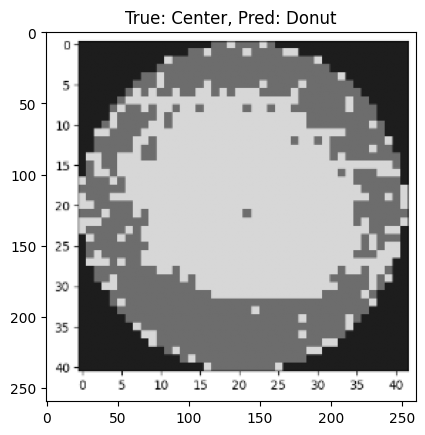

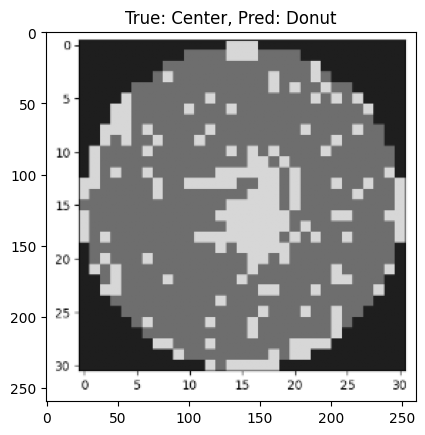

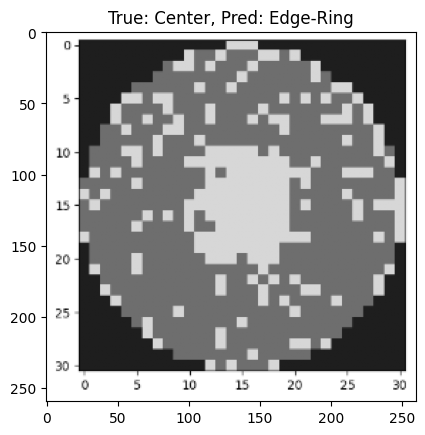

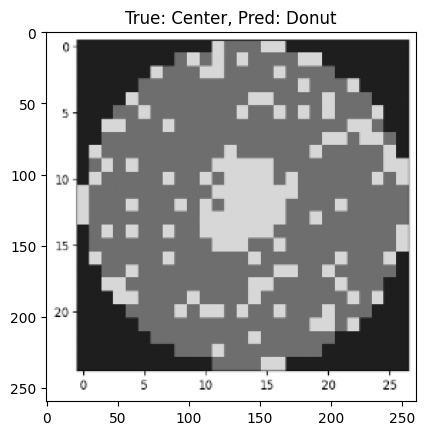

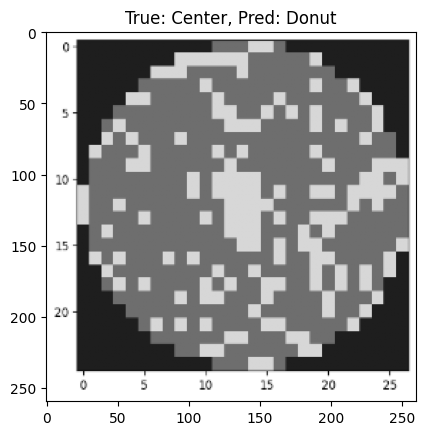

In [52]:
import matplotlib.pyplot as plt
idxs = np.where(y_val == 0)[0]  # Center samples
for i in idxs[:5]:
    plt.imshow(X_val[i], cmap='gray')
    plt.title(f"True: {classes[0]}, Pred: {classes[y_pred_label[i]]}")
    plt.show()


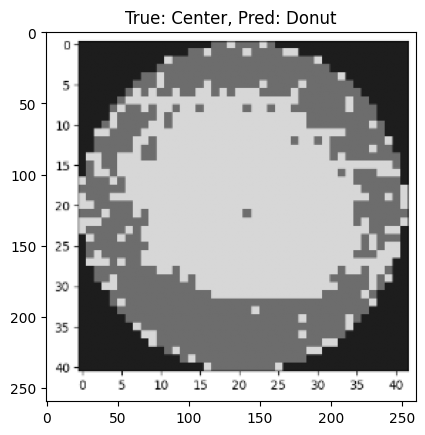

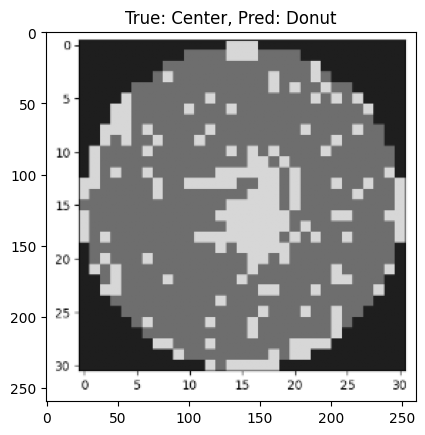

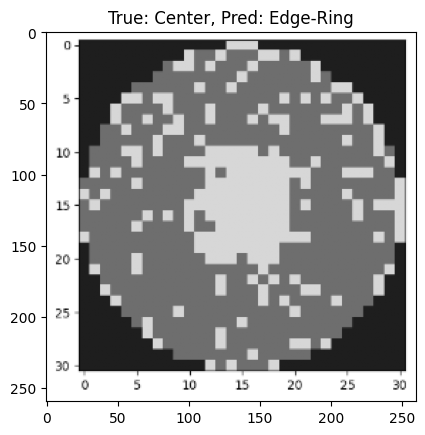

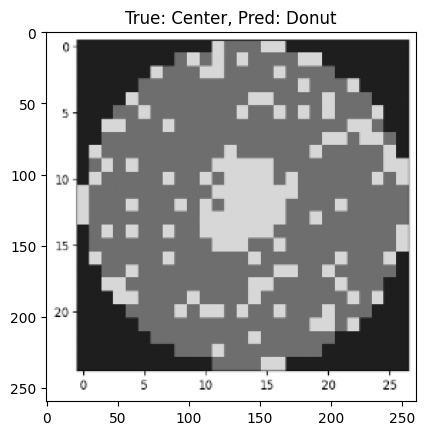

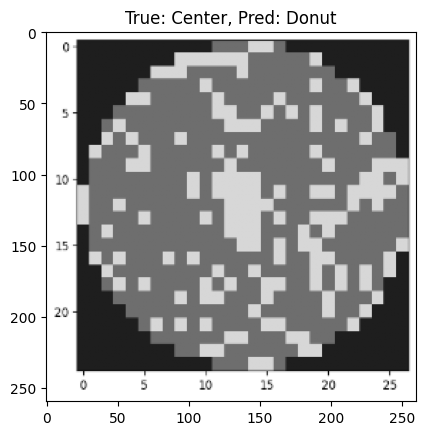

In [53]:
import matplotlib.pyplot as plt
idxs = np.where(y_val == 0)[0]  # Center samples
for i in idxs[:5]:
    plt.imshow(X_val[i], cmap='gray')
    plt.title(f"True: {classes[0]}, Pred: {classes[y_pred_label[i]]}")
    plt.show()


In [54]:
import pandas as pd
from collections import Counter

# Assuming y_tr contains the integer labels from training set
class_counts = Counter(y_tr)
print("Training class counts:")
for cls, cnt in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"  {classes[cls]} : {cnt:,}")


Training class counts:
  none : 29,384
  Edge-Ring : 6,845
  Center : 2,771
  Edge-Loc : 1,942
  Loc : 1,299
  Random : 487
  Scratch : 401
  Donut : 327
  Near-full : 43


# Observed haeavy class imbalance, more weights on none ie wafer without defects, but edge-Ring seems to be heavily used

In [56]:
from sklearn.utils.class_weight import compute_class_weight

# y_tr is already a numpy array of integers (0‑based labels)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_tr),
    y=y_tr
)

# Map the weights back to each label
class_weights = dict(zip(np.unique(y_tr), class_weights_array))
print("Class weights:")
for cls, w in class_weights.items():
    print(f"  {classes[cls]} : {w:.3f}")


Class weights:
  Center : 1.744
  Donut : 14.780
  Edge-Loc : 2.489
  Edge-Ring : 0.706
  Loc : 3.721
  Random : 9.924
  Near-full : 112.401
  Scratch : 12.053
  none : 0.164


# Further optimization to adjsute class imbalance and 

In [57]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)


In [ ]:
import tensorflow as tf

def build_cnn(n_classes):
    inputs = tf.keras.Input(shape=(260, 260, 1))   # grayscale
    x = tf.keras.layers.Conv2D(32, 5, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)

    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)

    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(n_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

model = build_cnn(len(classes))
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy', 
    # Categorical since we will one‑hot encode labels it may be only integer lables 
    # planning change to sparse_categorical_crossentropy if using one hot enoding labels
    metrics=['accuracy']
)


In [ ]:
# One‑hot encoding for training / validation
y_tr_onehot = tf.keras.utils.to_categorical(y_tr, num_classes=len(classes))
y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes=len(classes))

# Pass the one‑hot arrays directly (no generator needed)
history = model.fit(
    X_tr, y_tr_onehot,
    validation_data=(X_val, y_val_onehot),
    epochs=10,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=5)
    ],
    class_weight=class_weights
)


In [48]:
print(y_pred_prob.shape)


(10875, 6)


In [23]:
import tensorflow as tf
import numpy as np
from tensorflow.python.client import device_lib
import keras

print("Keras version: ", keras.__version__)



print(device_lib.list_local_devices())

x = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
tensor = tf.convert_to_tensor(x)

print("Tensor: ", tensor)

# ========================================== define model ======================================
input_data = keras.Input(shape = (8,1))

# Data Encoder
dx = keras.layers.Dense(16, activation='relu')(input_data)

print("dx", dx.shape)

Keras version:  3.13.2
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 11780347555578137462
xla_global_id: -1
]
Tensor:  tf.Tensor(
[[1 2 3]
 [4 5 6]
 [7 8 9]], shape=(3, 3), dtype=int64)
dx (None, 8, 16)
